# 16 — EDA fase 7: síntesis

**Pregunta guía:** ¿qué decidimos y qué queda pendiente para el feature engineering?

Este notebook no calcula análisis nuevos: **lee las métricas ya guardadas** por las fases 1-6 (`docs/eda/metricas/*.json`) y las ordena en tres tablas:
1. hallazgo → decisión, priorizada;
2. variables: mantener, transformar o descartar;
3. riesgos para el modelado.

También genera una figura panorámica. Todas las cifras que aparecen en `docs/eda/informe_eda.md` y en `docs/eda/problemas_y_decisiones.md` salen de estas tablas y quedan copiadas en `docs/eda/metricas/fase7_sintesis.json`.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.paths import EDA_METRICAS
from src.eda.carga import cargar_integrado, OBJETIVO
from src.eda.temporal import asignar_temporada
from src.eda.estilo import aplicar_estilo, guardar_figura, guardar_metricas, COLORES

aplicar_estilo()
FASE = "fase7_sintesis"
FASES = ["fase1_integridad_calidad", "fase2_variable_objetivo", "fase3_temporal", "fase4_espacial", "fase5_clima", "fase6_sociodemografico"]
MET = {f: json.loads((EDA_METRICAS / f"{f}.json").read_text(encoding="utf-8")) for f in FASES}

def m(fase, *ruta):
    """Lee una cifra de las métricas de una fase siguiendo la ruta de claves (falla si no existe)."""
    v = MET[fase]
    for k in ruta:
        v = v[str(k)]
    return v

M = {}
print({f: len(v) for f, v in MET.items()})

{'fase1_integridad_calidad': 106, 'fase2_variable_objetivo': 51, 'fase3_temporal': 41, 'fase4_espacial': 36, 'fase5_clima': 30, 'fase6_sociodemografico': 29}


## 1. Cifras clave por fase

Solo las cifras que sostienen las decisiones. Cada una se lee del JSON de su fase.

In [2]:
c = {
    # Fase 1
    "panel_filas": m("fase1_integridad_calidad", "n_filas"),
    "calendario_diverge_desde": m("fase1_integridad_calidad", "primera_semana_regla_pipeline_difiere_mmwr"),
    "casos_S53_2025_fuera": m("fase1_integridad_calidad", "sala_casos_fuera_del_panel"),
    "columnas_identicas": m("fase1_integridad_calidad", "pares_columnas_identicas"),
    "crec_pob_2017_2018_mediana_pct": m("fase1_integridad_calidad", "crec_pob_2018_mediana_pct"),
    "crec_pob_2019_2025_mediana_pct": m("fase1_integridad_calidad", "crec_pob_2019_2025_mediana_pct"),
    "distritos_nunca_en_excel": m("fase1_integridad_calidad", "distritos_nunca_en_excel"),
    "casos_2025": m("fase1_integridad_calidad", "casos_panel_2025"),
    "distritos_clima_compartido": m("fase1_integridad_calidad", "n_distritos_en_pares_clima_identico"),
    # Fase 2
    "pct_ceros": m("fase2_variable_objetivo", "pct_ceros"),
    "varianza_sobre_media": m("fase2_variable_objetivo", "varianza_sobre_media"),
    "distritos_50pct_casos": m("fase2_variable_objetivo", "distritos_para_50pct_casos"),
    "pct_casos_2017_2023_2024": m("fase2_variable_objetivo", "pct_casos_2017_2023_2024"),
    "anios_pre2017_mas_5000_casos": m("fase2_variable_objetivo", "excel_historia_anios_mas_de_5000_casos"),
    "pct_positivos_D1": m("fase2_variable_objetivo", "definiciones", "D1 tasa ≥ 10/100k", "pct_filas_positivas"),
    "pct_positivos_D4": m("fase2_variable_objetivo", "definiciones", "D4 aumento sostenido", "pct_filas_positivas"),
    "D3_pct_canal_en_cero": m("fase2_variable_objetivo", "D3_pct_distrito_semanas_con_canal_en_cero"),
    # Fase 3
    "semana_valle": m("fase3_temporal", "semana_valle"),
    "acf_r4_sin_nivel": m("fase3_temporal", "acf_distrital_sin_nivel_temporada_mediana_rezagos_1_4_8", 4),
    "acf_r8_sin_nivel": m("fase3_temporal", "acf_distrital_sin_nivel_temporada_mediana_rezagos_1_4_8", 8),
    "f1_persistencia_D1": m("fase3_temporal", "binaria_D1", "persistencia", "f1"),
    "pct_positivos_que_son_arranques": m("fase3_temporal", "arranques_pct_de_positivos"),
    "temporadas_menos_50_D1": m("fase3_temporal", "temporadas_con_menos_de_umbral_D1"),
    "min_casos_entre_picos_2023_2024": m("fase3_temporal", "min_casos_regionales_semanales_entre_picos_2023_2024"),
    # Fase 4
    "moran_knn5": round(m("fase4_espacial", "moran", "todos_knn5", "I"), 3),
    "moran_costa": round(m("fase4_espacial", "moran", "costa_knn5", "I"), 3),
    "rr_vecino_arranque": m("fase4_espacial", "rr_mh_vecino_con_D1_t_menos_4"),
    "rr_vecino_ic95": m("fase4_espacial", "rr_mh_ic95_bootstrap_temporadas"),
    "rr_vecino_t4": m("fase4_espacial", "rr_mh_candidatas_definidas_en_t_menos_4"),
    "mantel_residual_p": m("fase4_espacial", "mantel_residual_vs_distancia", "p_valor"),
    # Fase 5
    "temp_media_bruta_vs_anomalia": [m("fase5_clima", "mejor_rezago_ge_4", "temp_media", "distrital_bruta", "rho"),
                                     m("fase5_clima", "mejor_rezago_ge_4", "temp_media", "distrital_anomalia", "rho")],
    "rho_humedad_v48": m("fase5_clima", "robustez_ventana_4_8", "hum_rel_media", "todas"),
    "rho_precip_v48": m("fase5_clima", "robustez_ventana_4_8", "precip_total_mm", "todas"),
    "clima_ic_excluye_0": m("fase5_clima", "variables_ic95_excluye_0"),
    "parcial_humedad": m("fase5_clima", "corr_parcial_v48_controlando_casos_t4", "hum_rel_media"),
    "parcial_precip": m("fase5_clima", "corr_parcial_v48_controlando_casos_t4", "precip_total_mm"),
    "clima_arranques_ic_excluye_0": m("fase5_clima", "arranques_variables_ic95_excluye_0"),
    # Fase 6
    "var_cp1_socio": m("fase6_sociodemografico", "varianza_explicada_cp", "CP1"),
    "rho_cp1_costa_provincia": m("fase6_sociodemografico", "cp1_rho_por_definicion_de_zona", "costa_provincia", "rho"),
    "rho_cp1_costa_calidos": m("fase6_sociodemografico", "cp1_rho_por_definicion_de_zona", "costa_y_calidos", "rho"),
    "ic_cp1_costa_calidos": [m("fase6_sociodemografico", "cp1_rho_por_definicion_de_zona", "costa_y_calidos", "ic95_inf"),
                             m("fase6_sociodemografico", "cp1_rho_por_definicion_de_zona", "costa_y_calidos", "ic95_sup")],
    "socio_orden_inestable": m("fase6_sociodemografico", "variables_orden_distrital_inestable_rho_lt_0_8"),
}
c["rho_cp1_todos_los_distritos"] = m("fase6_sociodemografico", "spearman_con_log_incidencia", "CP1", "rho_todos")
M["cifras_clave"] = c
pd.Series({k: str(v) for k, v in c.items()}).to_frame("valor")

,valor
panel_filas,30485
calendario_diverge_desde,2025-12-28
casos_S53_2025_fuera,3
columnas_identicas,"[['precip_total_mm', 'lluvia_total_mm']]"
crec_pob_2017_2018_mediana_pct,6.8
crec_pob_2019_2025_mediana_pct,0.67
distritos_nunca_en_excel,"['200204 Lagunas', '200205 Montero', '200209 S..."
casos_2025,1114
distritos_clima_compartido,8
pct_ceros,77.93


## 2. Tabla hallazgo → decisión (priorizada)

Prioridad:
- **A**: condiciona el diseño del modelo o la validez de la evaluación;
- **B**: mejora el modelo o su interpretación;
- **C**: orden o documentación.

Tipo de decisión:
- **FE**: feature engineering;
- **OBJ**: definición del objetivo;
- **VAL**: validación;
- **DATOS**: corrección en el pipeline;
- **ASESOR**: pregunta al asesor.

In [3]:
fila = lambda prio, tipo, fase, hallazgo, cifra, decision: dict(prioridad=prio, tipo=tipo, fase=fase, hallazgo=hallazgo, cifra_clave=cifra, recomendacion=decision)
tabla = pd.DataFrame([
    fila("A", "VAL", 3, "Persistencia a 4 semanas es una línea base exigente",
         f"F1 D1 = {c['f1_persistencia_D1']}", "Todo modelo se compara contra la persistencia a 4 semanas; métricas por temporada y aparte en arranques"),
    fila("A", "VAL", 3, "Pocas temporadas con brotes; 2023 y 2024 conectadas",
         f"temporadas con < 50 positivos D1: {c['temporadas_menos_50_D1']}; mínimo entre picos 2023-24: {c['min_casos_entre_picos_2023_2024']} casos/sem",
         "Origen móvil por temporada (corte en la semana {}), sin partición aleatoria, con margen ≥ horizonte + rezago máximo".format(c["semana_valle"])),
    fila("A", "OBJ", 2, "Objetivo con muchos ceros y sobredisperso",
         f"{c['pct_ceros']} % ceros; varianza/media = {c['varianza_sobre_media']}", "Conteo con población como exposición (NB/ceros inflados) o clasificación binaria; no Poisson simple"),
    fila("A", "OBJ", 2, "Las definiciones de brote difieren en desbalance y sentido",
         f"D1 = {c['pct_positivos_D1']} % positivos; D4 = {c['pct_positivos_D4']} %; D3 con canal en 0 en {c['D3_pct_canal_en_cero']} %",
         "Elegir con el asesor: nivel (D1/D3 corregido) o arranque (D4)"),
    fila("A", "DATOS", 1, "Calendario del pipeline diverge de MMWR",
         f"desde {c['calendario_diverge_desde']}; {c['casos_S53_2025_fuera']} casos de 2025-S53 fuera",
         "Corregir la regla de semana antes de actualizar a 2026"),
    fila("A", "DATOS", 1, "2025 viene de otra fuente (posible subregistro)",
         f"{c['casos_2025']} casos en 2025", "No usar 2025 como temporada comparable sin advertencia; decidir su uso"),
    fila("A", "FE", 3, "Rezagos útiles a horizonte 4",
         f"ACF sin nivel: r4 = {c['acf_r4_sin_nivel']}, r8 = {c['acf_r8_sin_nivel']}", "Rezago 4-5 de casos + resúmenes del nivel reciente; nunca rezagos < 4"),
    fila("A", "FE", 4, "Vecinos con brote en t-4 se asocian a más arranques",
         f"RR MH = {c['rr_vecino_arranque']} (IC95 % {c['rr_vecino_ic95']}); con candidatas en t-4: {c['rr_vecino_t4']}",
         "Incluir estado rezagado (≥ 4) de vecinos; definir k/radio en FE"),
    fila("B", "FE", 5, "Clima: solo humedad y precipitación robustas",
         f"rho ventana 4-8: humedad {c['rho_humedad_v48']}, precip {c['rho_precip_v48']}; parcial | casos t-4: {c['parcial_humedad']}, {c['parcial_precip']}",
         "Anomalías rezagadas (ventana 4-8) de humedad y precipitación; climatología solo con entrenamiento"),
    fila("B", "FE", 5, "Temperatura media/máxima = calendario",
         f"rho temp_media bruta vs anomalía: {c['temp_media_bruta_vs_anomalia']}", "No usar temperatura cruda como señal de clima; la semana epidemiológica ya aporta calendario"),
    fila("B", "FE", 6, "Sociodemografía = un eje urbano, débil dentro de la zona cálida",
         f"CP1 = {c['var_cp1_socio']} de la varianza; rho costa y cálidos = {c['rho_cp1_costa_calidos']} (IC {c['ic_cp1_costa_calidos']})",
         "A lo sumo el CP1 (o 2-3 variables) fijado en 2017, como rasgo estático; o descartarla"),
    fila("B", "FE", 4, "Autocorrelación espacial positiva",
         f"I de Moran = {c['moran_knn5']} (solo costa {c['moran_costa']})", "Modelo global con nivel propio del distrito; validación por tiempo, no por distrito"),
    fila("B", "DATOS", 1, "Salto de población 2017→2018",
         f"mediana +{c['crec_pob_2017_2018_mediana_pct']} % vs +{c['crec_pob_2019_2025_mediana_pct']} %/año después", "Confirmar la fuente de 2017 antes de usar tasas"),
    fila("B", "ASESOR", 2, "Hay temporadas grandes antes de 2017 en el Excel",
         f"años pre-2017 con > 5 000 casos: {c['anios_pre2017_mas_5000_casos']}", "Evaluar ampliar el panel hacia atrás"),
    fila("C", "DATOS", 1, "lluvia_total_mm ≡ precip_total_mm", f"{c['columnas_identicas']}", "Usar solo precip_total_mm"),
    fila("C", "DATOS", 1, "Tres distritos nunca aparecen en el Excel", f"{c['distritos_nunca_en_excel']}", "Decidir exclusión o tratarlos como sin casos"),
    fila("C", "DATOS", 6, "Orden distrital inestable 2017→2025 en algunas fracciones", f"{c['socio_orden_inestable']}", "Revisar la fuente socio de cada año"),
])
tabla = tabla.sort_values(["prioridad", "fase"]).reset_index(drop=True)
M["tabla_decisiones"] = tabla.to_dict("records")
M["n_decisiones_por_prioridad"] = {k: int(v) for k, v in tabla["prioridad"].value_counts().sort_index().items()}
pd.set_option("display.max_colwidth", 120)
tabla

,prioridad,tipo,fase,hallazgo,cifra_clave,recomendacion
0,A,DATOS,1,Calendario del pipeline diverge de MMWR,desde 2025-12-28; 3 casos de 2025-S53 fuera,Corregir la regla de semana antes de actualizar a 2026
1,A,DATOS,1,2025 viene de otra fuente (posible subregistro),1114 casos en 2025,No usar 2025 como temporada comparable sin advertencia; decidir su uso
2,A,OBJ,2,Objetivo con muchos ceros y sobredisperso,77.93 % ceros; varianza/media = 360.1,Conteo con población como exposición (NB/ceros inflados) o clasificación binaria; no Poisson simple
3,A,OBJ,2,Las definiciones de brote difieren en desbalance y sentido,D1 = 13.37 % positivos; D4 = 2.48 %; D3 con canal en 0 en 73.9 %,Elegir con el asesor: nivel (D1/D3 corregido) o arranque (D4)
4,A,VAL,3,Persistencia a 4 semanas es una línea base exigente,F1 D1 = 0.735,Todo modelo se compara contra la persistencia a 4 semanas; métricas por temporada y aparte en arranques
5,A,VAL,3,Pocas temporadas con brotes; 2023 y 2024 conectadas,"temporadas con < 50 positivos D1: [2019, 2020, 2026]; mínimo entre picos 2023-24: 141 casos/sem","Origen móvil por temporada (corte en la semana 35), sin partición aleatoria, con margen ≥ horizonte + rezago máximo"
6,A,FE,3,Rezagos útiles a horizonte 4,"ACF sin nivel: r4 = 0.643, r8 = 0.29",Rezago 4-5 de casos + resúmenes del nivel reciente; nunca rezagos < 4
7,A,FE,4,Vecinos con brote en t-4 se asocian a más arranques,"RR MH = 2.82 (IC95 % [1.87, 4.29]); con candidatas en t-4: 3.46",Incluir estado rezagado (≥ 4) de vecinos; definir k/radio en FE
8,B,DATOS,1,Salto de población 2017→2018,mediana +6.8 % vs +0.67 %/año después,Confirmar la fuente de 2017 antes de usar tasas
9,B,ASESOR,2,Hay temporadas grandes antes de 2017 en el Excel,"años pre-2017 con > 5 000 casos: [2001, 2010, 2015, 2016]",Evaluar ampliar el panel hacia atrás


## 3. Variables: mantener, transformar o descartar

In [4]:
variables = pd.DataFrame([
    ("casos_Dengue (rezagos ≥ 4)", "Mantener y transformar", "Predictor más fuerte; log1p o conteo con exposición"),
    ("semana epidemiológica", "Mantener", "Estacionalidad clara (valle en la semana {})".format(c["semana_valle"])),
    ("estado de vecinos (rezago ≥ 4)", "Construir (FE)", "RR de arranque ≈ {}".format(c["rr_vecino_arranque"])),
    ("hum_rel_media", "Transformar", "Anomalía rezagada 4-8; asociación robusta"),
    ("precip_total_mm", "Transformar", "Anomalía rezagada 4-8; asociación robusta"),
    ("temp_min", "Opcional", "Asociación dependiente de 2024; no robusta"),
    ("temp_media, temp_max", "Descartar como clima", "Solo aportan calendario"),
    ("radiacion_total, et0_total, viento_max", "Descartar (redundantes)", "Redundantes con humedad; IC incluye 0"),
    ("lluvia_total_mm", "Descartar", "Idéntica a precip_total_mm"),
    ("15 fraccion_*", "Reducir", "CP1 o 2-3 variables, fijadas en 2017; asociación débil dentro de la zona cálida"),
    ("poblacion", "Mantener como exposición", "Denominador u offset; revisar el salto 2017→2018"),
    ("lat, lon", "Uso indirecto", "Para definir vecinos; no como predictor directo"),
], columns=["variable", "recomendacion", "motivo"])
M["variables"] = variables.to_dict("records")
variables

,variable,recomendacion,motivo
0,casos_Dengue (rezagos ≥ 4),Mantener y transformar,Predictor más fuerte; log1p o conteo con exposición
1,semana epidemiológica,Mantener,Estacionalidad clara (valle en la semana 35)
2,estado de vecinos (rezago ≥ 4),Construir (FE),RR de arranque ≈ 2.82
3,hum_rel_media,Transformar,Anomalía rezagada 4-8; asociación robusta
4,precip_total_mm,Transformar,Anomalía rezagada 4-8; asociación robusta
5,temp_min,Opcional,Asociación dependiente de 2024; no robusta
6,"temp_media, temp_max",Descartar como clima,Solo aportan calendario
7,"radiacion_total, et0_total, viento_max",Descartar (redundantes),Redundantes con humedad; IC incluye 0
8,lluvia_total_mm,Descartar,Idéntica a precip_total_mm
9,15 fraccion_*,Reducir,"CP1 o 2-3 variables, fijadas en 2017; asociación débil dentro de la zona cálida"


## 4. Riesgos para el modelado

In [5]:
riesgos = pd.DataFrame([
    ("Fuga de información (leakage)", "Rezagos < horizonte; climatologías, perfiles, percentiles o escaladores con todo el periodo; sociodemografía interpolada hacia 2025; población proyectada; partición aleatoria"),
    ("Dependencia de pocos brotes", f"{c['pct_casos_2017_2023_2024']} % de los casos en 2017, 2023 y 2024"),
    ("Subregistro 2025", f"{c['casos_2025']} casos, otra fuente"),
    ("Sobredispersión y ceros", f"{c['pct_ceros']} % ceros; varianza/media {c['varianza_sobre_media']}"),
    ("Desbalance de clases", f"D1 {c['pct_positivos_D1']} %, D4 {c['pct_positivos_D4']} % de positivos"),
    ("Clima de baja resolución", f"{c['distritos_clima_compartido']} distritos comparten serie climática con un vecino"),
    ("Concentración espacial", f"{c['distritos_50pct_casos']} distritos suman el 50 % de los casos"),
], columns=["riesgo", "evidencia"])
M["riesgos"] = riesgos.to_dict("records")
riesgos

,riesgo,evidencia
0,Fuga de información (leakage),"Rezagos < horizonte; climatologías, perfiles, percentiles o escaladores con todo el periodo; sociodemografía interpo..."
1,Dependencia de pocos brotes,"89.6 % de los casos en 2017, 2023 y 2024"
2,Subregistro 2025,"1114 casos, otra fuente"
3,Sobredispersión y ceros,77.93 % ceros; varianza/media 360.1
4,Desbalance de clases,"D1 13.37 %, D4 2.48 % de positivos"
5,Clima de baja resolución,8 distritos comparten serie climática con un vecino
6,Concentración espacial,5 distritos suman el 50 % de los casos


## 5. Panorama del dataset

Una sola figura que resume la estructura temporal que condiciona el modelado: las temporadas, los regímenes, la ruptura de fuente de 2025 y el corte de temporada.

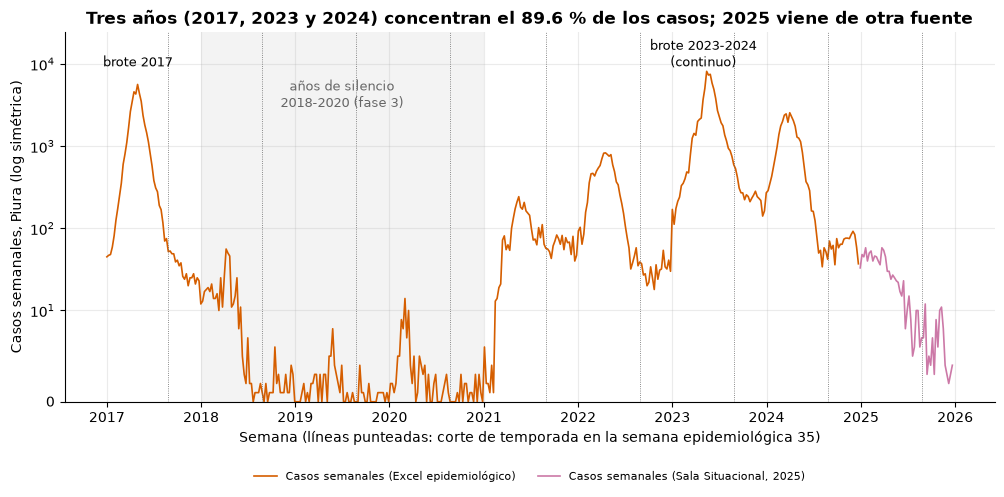

In [6]:
df = cargar_integrado()
df["temporada"] = asignar_temporada(df["anio"], df["semana"], c["semana_valle"])
reg = df.groupby("semana_inicio").agg(casos=(OBJETIVO, "sum"), temporada=("temporada", "first"))
fig, ax = plt.subplots(figsize=(12, 4.8))
es_sala = reg.index >= pd.Timestamp("2024-12-29")
ax.plot(reg.index[~es_sala], reg["casos"][~es_sala], color=COLORES["casos"], lw=1.2, label="Casos semanales (Excel epidemiológico)")
ax.plot(reg.index[es_sala], reg["casos"][es_sala], color=COLORES["resalte"], lw=1.2, label="Casos semanales (Sala Situacional, 2025)")
cortes = reg.index[reg["temporada"].ne(reg["temporada"].shift())][1:]
for f in cortes:
    ax.axvline(f, color=COLORES["referencia"], lw=0.6, ls=":")
ax.axvspan(pd.Timestamp("2018-01-01"), pd.Timestamp("2020-12-31"), color=COLORES["referencia"], alpha=0.08, lw=0)
ax.text(pd.Timestamp("2019-07-01"), 3000, "años de silencio\n2018-2020 (fase 3)", ha="center", fontsize=9, color=COLORES["referencia"])
for anio, txt in [(2017, "brote 2017"), (2023, "brote 2023-2024\n(continuo)")]:
    ax.text(pd.Timestamp(f"{anio}-05-01"), reg["casos"].max() * 1.15, txt, ha="center", fontsize=9)
ax.set_yscale("symlog", linthresh=10)
ax.set_ylim(bottom=0, top=reg["casos"].max() * 3)
ax.set(xlabel=f"Semana (líneas punteadas: corte de temporada en la semana epidemiológica {c['semana_valle']})",
       ylabel="Casos semanales, Piura (log simétrica)",
       title=f"Tres años (2017, 2023 y 2024) concentran el {c['pct_casos_2017_2023_2024']} % de los casos; 2025 viene de otra fuente")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncols=2, fontsize=8)
guardar_figura(fig, FASE, "01_panorama")
plt.show()

In [7]:
ruta = guardar_metricas(FASE, M)
print("Métricas guardadas en", ruta.relative_to(ruta.parents[3]))

Métricas guardadas en docs\eda\metricas\fase7_sintesis.json
